# Customer Data Cleaning Pipeline

**Project:** Online-store customer dataset  
**Purpose:** A single, reproducible notebook that identifies the source workbook, assesses data quality, applies every reviewed cleaning decision, records row-level changes, validates the final dataset, and exports a cleaned Excel workbook.

## Pipeline map

1. Discover and read the raw Excel workbook and JSON rule file.
2. Run a non-destructive data-quality assessment.
3. Fill missing values and remove the full duplicate record.
4. Correct impossible `returned_items` values.
5. Review `total_spending` outliers and correct only formula errors.
6. Standardize `total_spending` to three decimal places.
7. Replace implausible ages.
8. Standardize city/province values from the reviewed location reference.
9. Correct `gender` from the validated name-gender reference.
10. Convert `signup_date` from object/string to a typed datetime column.
11. Encode `gender` with the explicit binary rule `F = 0`, `M = 1`.
12. Run final validation, export the cleaned Excel dataset, and create a before/after summary.

> The raw workbook is read-only. After final validation passes, the cleaned dataset is exported to `data/cleaned_dataset_FatemehDehghan224.xlsx`; audit tables, charts, and validation results are displayed inside the notebook.

## 0. Environment and project paths

This section imports the required libraries and finds the project root whether the notebook is launched from the repository root or from `clean_data_code/`. The raw workbook and the version-controlled name-gender JSON reference are inputs; the workflow writes one validated cleaned Excel workbook to `data/`.

In [56]:
from __future__ import annotations

import itertools
import json
from datetime import date
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib

try:
    from IPython import get_ipython
except ImportError:
    get_ipython = lambda: None

if get_ipython() is None:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import pandas as pd
try:
    from IPython.display import display
except ImportError:  # Allows script-style validation outside Jupyter.
    def display(value):
        """Print a value when IPython's rich display function is unavailable."""
        print(value)
from pandas.api.types import is_numeric_dtype

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

RAW_FILENAME = "raw_dataset_FatemehDehghan224.xlsx"
CLEANED_FILENAME = "cleaned_dataset_FatemehDehghan224.xlsx"
NAME_GENDER_MAPPING_FILENAME = "name_gender_mapping.json"
ALLOWED_GENDER_CODES = {"M", "F"}
GENDER_BINARY_MAPPING = {"F": 0, "M": 1}
BINARY_GENDER_CODES = set(GENDER_BINARY_MAPPING.values())
PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents)
     if (candidate / "data" / RAW_FILENAME).exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate data/{RAW_FILENAME}. Start the notebook from the project directory."
    )

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_DIR / RAW_FILENAME
CLEANED_DATA_PATH = DATA_DIR / CLEANED_FILENAME
NAME_GENDER_MAPPING_PATH = PROJECT_ROOT / "clean_data_code" / NAME_GENDER_MAPPING_FILENAME

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw input:      {RAW_DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Rule input:     {NAME_GENDER_MAPPING_PATH.relative_to(PROJECT_ROOT)}")
print(f"Cleaned output: {CLEANED_DATA_PATH.relative_to(PROJECT_ROOT)}")

Project root: F:\Data Analysis\project-01-data-cleaning-FatemehDehghan224\studybuild-data-cleaning-01\submissions\FatemehDehghan224
Raw input:      data\raw_dataset_FatemehDehghan224.xlsx
Rule input:     clean_data_code\name_gender_mapping.json
Cleaned output: data\cleaned_dataset_FatemehDehghan224.xlsx


## 1. Discover and read the input files

Before cleaning, the code identifies the Excel source available in `data/`, confirms that the expected `customers` sheet exists, and loads the raw workbook. It also loads and validates `clean_data_code/name_gender_mapping.json`, the explicit reference used to audit and correct the `gender` column.

In [57]:
excel_inventory = pd.DataFrame(
    [
        {
            "file": path.name,
            "size_kb": round(path.stat().st_size / 1024, 1),
            "role": (
                "raw source" if path == RAW_DATA_PATH
                else "cleaned output" if path == CLEANED_DATA_PATH
                else "other workbook"
            ),
        }
        for path in sorted(DATA_DIR.glob("*.xlsx"))
    ]
)
display(excel_inventory)

workbook = pd.ExcelFile(RAW_DATA_PATH)
if "customers" not in workbook.sheet_names:
    raise ValueError(
        f"Expected sheet 'customers' was not found. Available sheets: {workbook.sheet_names}"
    )

raw_df = pd.read_excel(RAW_DATA_PATH, sheet_name="customers")
print(f"Workbook sheets: {workbook.sheet_names}")
print(f"Loaded shape: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns")
display(raw_df.head())

with NAME_GENDER_MAPPING_PATH.open(encoding="utf-8") as mapping_file:
    name_gender_mapping = json.load(mapping_file)

if not isinstance(name_gender_mapping, dict) or not name_gender_mapping:
    raise ValueError("The name–gender mapping must be a non-empty JSON object.")

normalized_name_gender_mapping = {}
for name, gender in name_gender_mapping.items():
    if not isinstance(name, str) or not name.strip():
        raise ValueError(f"Invalid name key in {NAME_GENDER_MAPPING_FILENAME}: {name!r}")
    if not isinstance(gender, str) or gender.strip().upper() not in ALLOWED_GENDER_CODES:
        raise ValueError(f"Invalid gender code for {name!r}: {gender!r}; expected M or F.")
    normalized_name = " ".join(name.strip().split()).casefold()
    if normalized_name in normalized_name_gender_mapping:
        raise ValueError(f"Duplicate normalized name in mapping: {name!r}")
    normalized_name_gender_mapping[normalized_name] = gender.strip().upper()

dataset_normalized_names = raw_df["first_name"].map(
    lambda value: " ".join(value.strip().split()).casefold() if isinstance(value, str) else value
)
unmapped_input_names = sorted(
    raw_df.loc[~dataset_normalized_names.isin(normalized_name_gender_mapping), "first_name"]
    .dropna().astype(str).unique().tolist()
)
if unmapped_input_names:
    raise ValueError(
        f"Names missing from {NAME_GENDER_MAPPING_FILENAME}: {unmapped_input_names}"
    )

name_gender_reference = pd.DataFrame(
    sorted(name_gender_mapping.items()), columns=["first_name", "expected_gender"]
)
print(f"Validated name–gender rules: {len(name_gender_reference)} names; all input names covered.")
display(name_gender_reference)

,file,size_kb,role
0,raw_dataset_FatemehDehghan224.xlsx,10.4,raw source


Workbook sheets: ['customers']
Loaded shape: 61 rows x 17 columns


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


Validated name–gender rules: 12 names; all input names covered.


,first_name,expected_gender
0,Ali,M
1,Amir,M
2,Arash,M
3,Kimia,F
4,Maryam,F
5,Mina,F
6,Neda,F
7,Parsa,M
8,Reza,M
9,Sara,F


In [58]:
source_profile = pd.DataFrame(
    {
        "column": raw_df.columns,
        "dtype": raw_df.dtypes.astype(str).values,
        "non_null": raw_df.notna().sum().values,
        "missing": raw_df.isna().sum().values,
        "unique": [raw_df[column].nunique(dropna=False) for column in raw_df.columns],
    }
)
display(source_profile)

,column,dtype,non_null,missing,unique
0,customer_id,int64,61,0,60
1,first_name,object,61,0,12
2,gender,object,61,0,2
3,age,float64,60,1,35
4,city,object,61,0,8
5,province,object,61,0,8
6,signup_date,object,61,0,58
7,membership_tier,object,61,0,4
8,purchase_count,int64,61,0,30
9,avg_order_value,float64,61,0,60


## 2. Data-quality rules

The expected schema and allowed categorical values are explicit rather than hidden inside individual cleaning cells. This makes the notebook auditable and gives future project stages one place to update business rules.

Key logical rules used in this project:

- A plausible customer age is between 13 and 100.
- Counts and monetary values cannot be negative.
- `satisfaction_score` must be an integer from 1 to 5.
- `returned_items` cannot exceed `purchase_count`.
- `total_spending` is a derived value: `purchase_count * avg_order_value`, rounded and displayed to three decimal places.
- City and province values must match the reviewed location reference; aliases such as `Khorasan` are standardized to the full province name used by the project.
- Every normalized `first_name` must exist in `name_gender_mapping.json`, and `gender` must equal its mapped `M` or `F` value.

In [59]:
EXPECTED_SCHEMA = {
    "customer_id": "integer",
    "first_name": "text",
    "gender": "category",
    "age": "numeric",
    "city": "text",
    "province": "text",
    "signup_date": "date",
    "membership_tier": "category",
    "purchase_count": "integer",
    "avg_order_value": "numeric",
    "total_spending": "numeric",
    "last_purchase_days": "integer",
    "payment_method": "category",
    "device": "category",
    "discount_used": "category",
    "returned_items": "integer",
    "satisfaction_score": "integer",
}

ALLOWED_VALUES = {
    "gender": ALLOWED_GENDER_CODES,
    "membership_tier": {"Bronze", "Silver", "Gold", "VIP"},
    "payment_method": {"Card", "Cash", "Online Wallet"},
    "device": {"Android", "iPhone", "Web"},
    "discount_used": {"Yes", "No"},
}

CITY_PROVINCE_REFERENCE = {
    "Ahvaz": "Khuzestan",
    "Isfahan": "Isfahan",
    "Karaj": "Alborz",
    "Mashhad": "Khorasan Razavi",
    "Rasht": "Guilan",
    "Shiraz": "Fars",
    "Tabriz": "East Azerbaijan",
    "Tehran": "Tehran",
}

CITY_ALIASES = {
    "ahvaz": "Ahvaz",
    "isfahan": "Isfahan",
    "esfahan": "Isfahan",
    "karaj": "Karaj",
    "mashhad": "Mashhad",
    "rasht": "Rasht",
    "shiraz": "Shiraz",
    "tabriz": "Tabriz",
    "tehran": "Tehran",
}

PROVINCE_ALIASES = {
    "alborz": "Alborz",
    "east azerbaijan": "East Azerbaijan",
    "fars": "Fars",
    "gilan": "Guilan",
    "guilan": "Guilan",
    "giluan": "Guilan",
    "isfahan": "Isfahan",
    "esfahan": "Isfahan",
    "khorasan": "Khorasan Razavi",
    "khorasan razavi": "Khorasan Razavi",
    "khuzestan": "Khuzestan",
    "tehran": "Tehran",
}

LOCATION_SIMILARITY_THRESHOLD = 0.84

NUMERIC_COLUMNS = [
    "age", "purchase_count", "avg_order_value", "total_spending",
    "last_purchase_days", "returned_items", "satisfaction_score",
]
TOTAL_SPENDING_DECIMALS = 3
SPENDING_TOLERANCE = 0.5 * 10 ** (-TOTAL_SPENDING_DECIMALS)
TOTAL_SPENDING_DISPLAY_FORMAT = "{:.3f}"

CHANGE_COLUMNS = [
    "stage", "action", "source_excel_row", "customer_id", "column",
    "old_value", "new_value", "rule", "reason",
]

def with_excel_row(df: pd.DataFrame, column_name: str = "excel_row") -> pd.DataFrame:
    """Return a copy with a leading column containing source Excel row numbers.

    The two-row offset accounts for pandas' zero-based index and the Excel header row.
    The input DataFrame is not modified.
    """
    result = df.copy()
    result.insert(0, column_name, result.index + 2)
    return result

def change_record(*, stage: str, action: str, source_excel_row: int, customer_id: object,
                  column: str, old_value: object, new_value: object, rule: str, reason: str) -> dict:
    """Build one normalized row-level audit record for a cleaning action.

    Returns a dictionary aligned with ``CHANGE_COLUMNS`` so records from every
    cleaning stage can be concatenated into a consistent audit table.
    """
    return {
        "stage": stage, "action": action, "source_excel_row": source_excel_row,
        "customer_id": customer_id, "column": column, "old_value": old_value,
        "new_value": new_value, "rule": rule, "reason": reason,
    }

def format_decimal_columns_for_display(df: pd.DataFrame, formats: dict[str, str]) -> pd.DataFrame:
    """Return a display-only copy with selected numeric columns formatted as strings."""
    result = df.copy()
    for column, number_format in formats.items():
        if column in result.columns:
            values = pd.to_numeric(result[column], errors="coerce")
            result[column] = values.map(lambda value: "" if pd.isna(value) else number_format.format(value))
    return result

## 3. Initial data-quality assessment

This stage is diagnostic only: it does not modify `raw_df`. It reproduces the original assessment checks and displays every summary, issue table, and IQR chart directly below the cells. The assessment covers column structure, missing values, duplicate records, data types, logical constraints, text consistency, and numerical outliers.

In [60]:
def assess_basic_info(df: pd.DataFrame) -> pd.DataFrame:
    """Summarize data type, completeness, and cardinality for each column.

    Args:
        df: Dataset to profile.

    Returns:
        One summary row per input column.
    """
    return pd.DataFrame({
        "column": df.columns,
        "dtype": [str(dtype) for dtype in df.dtypes],
        "non_null_count": [int(df[column].notna().sum()) for column in df.columns],
        "null_count": [int(df[column].isna().sum()) for column in df.columns],
        "unique_count": [int(df[column].nunique(dropna=False)) for column in df.columns],
    })

def assess_missing_values(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Calculate missing-value statistics and extract affected source rows.

    Args:
        df: Dataset to inspect.

    Returns:
        A column-level missing-value summary and all rows containing a missing value.
    """
    summary = (df.isna().sum().rename("missing_count").reset_index()
               .rename(columns={"index": "column"}))
    summary["missing_percent"] = (summary["missing_count"] / len(df) * 100).round(2)
    summary = summary.sort_values(["missing_count", "column"], ascending=[False, True])
    rows = with_excel_row(df[df.isna().any(axis=1)])
    return summary, rows

def assess_duplicates(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Identify full-row duplicates and duplicated customer identifiers.

    Args:
        df: Dataset to inspect.

    Returns:
        Full duplicate occurrences and rows sharing a ``customer_id``.
    """
    full_rows = with_excel_row(df[df.duplicated(keep=False)]).sort_values(list(df.columns))
    duplicate_ids = with_excel_row(
        df[df.duplicated(subset=["customer_id"], keep=False)]
    ).sort_values("customer_id")
    return full_rows, duplicate_ids

def invalid_type_mask(series: pd.Series, expected_type: str) -> pd.Series:
    """Return a Boolean mask for non-missing values that violate an expected type.

    Supported logical types are ``integer``, ``numeric``, ``date``, ``text``,
    and ``category``. Missing values are assessed separately and are not flagged here.
    """
    non_missing = series.notna()
    if expected_type in {"integer", "numeric"}:
        converted = pd.to_numeric(series, errors="coerce")
        invalid = non_missing & converted.isna()
        if expected_type == "integer":
            invalid |= non_missing & converted.notna() & (converted % 1 != 0)
        return invalid
    if expected_type == "date":
        return non_missing & pd.to_datetime(series, errors="coerce").isna()
    if expected_type in {"text", "category"}:
        return non_missing & ~series.map(lambda value: isinstance(value, str))
    return pd.Series(False, index=series.index)

def assess_data_types(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Compare dataset values with ``EXPECTED_SCHEMA`` type requirements.

    Args:
        df: Dataset to validate.

    Returns:
        A per-column type summary and a row-level table of invalid values.
    """
    summary_rows, invalid_rows = [], []
    for column, expected_type in EXPECTED_SCHEMA.items():
        if column not in df.columns:
            summary_rows.append({"column": column, "expected_type": expected_type,
                                 "actual_dtype": "missing_column", "invalid_value_count": None})
            continue
        mask = invalid_type_mask(df[column], expected_type)
        summary_rows.append({"column": column, "expected_type": expected_type,
                             "actual_dtype": str(df[column].dtype),
                             "invalid_value_count": int(mask.sum())})
        for idx, value in df.loc[mask, column].items():
            invalid_rows.append({"excel_row": idx + 2, "column": column, "value": value,
                                 "expected_type": expected_type,
                                 "actual_python_type": type(value).__name__})
    return pd.DataFrame(summary_rows), pd.DataFrame(
        invalid_rows, columns=["excel_row", "column", "value", "expected_type", "actual_python_type"]
    )

def assess_logical_values(df: pd.DataFrame) -> pd.DataFrame:
    """Find values that violate the project's numerical and business rules.

    Checks include plausible age, non-negative measures, integer counts, satisfaction
    range, returned-item limits, spending formula consistency, valid dates, and allowed
    categorical domains. The input dataset is not modified.
    """
    issues = []
    numeric = {column: pd.to_numeric(df[column], errors="coerce")
               for column in NUMERIC_COLUMNS if column in df.columns}

    def add_issue(mask: pd.Series, column: str, issue: str, expected: str) -> None:
        """Append standardized issue records for rows selected by ``mask``."""
        for idx, value in df.loc[mask, column].items():
            issues.append({"excel_row": idx + 2, "customer_id": df.at[idx, "customer_id"],
                           "column": column, "value": value, "issue": issue, "expected": expected})

    add_issue(numeric["age"].notna() & ~numeric["age"].between(13, 100),
              "age", "unrealistic_age", "13 to 100")
    for column in ["purchase_count", "avg_order_value", "total_spending",
                   "last_purchase_days", "returned_items"]:
        add_issue(numeric[column].notna() & (numeric[column] < 0), column, "negative_value", ">= 0")
    for column in ["purchase_count", "last_purchase_days", "returned_items", "satisfaction_score"]:
        add_issue(numeric[column].notna() & (numeric[column] % 1 != 0), column, "non_integer_value", "integer")
    add_issue(numeric["satisfaction_score"].notna() & ~numeric["satisfaction_score"].between(1, 5),
              "satisfaction_score", "score_out_of_range", "1 to 5")
    add_issue(numeric["returned_items"].notna() & numeric["purchase_count"].notna()
              & (numeric["returned_items"] > numeric["purchase_count"]),
              "returned_items", "returned_items_greater_than_purchase_count", "<= purchase_count")

    expected_total = (numeric["purchase_count"] * numeric["avg_order_value"]).round(TOTAL_SPENDING_DECIMALS)
    actual_total = numeric["total_spending"].round(TOTAL_SPENDING_DECIMALS)
    mismatch = actual_total.notna() & expected_total.notna() & ((actual_total - expected_total).abs() > SPENDING_TOLERANCE)
    for idx in df.index[mismatch]:
        issues.append({"excel_row": idx + 2, "customer_id": df.at[idx, "customer_id"],
                       "column": "total_spending", "value": df.at[idx, "total_spending"],
                       "issue": "total_spending_formula_mismatch",
                       "expected": f"purchase_count * avg_order_value = {expected_total.at[idx]}"})

    parsed_dates = pd.to_datetime(df["signup_date"], errors="coerce")
    add_issue(parsed_dates.isna() & df["signup_date"].notna(), "signup_date", "invalid_date", "valid date")
    add_issue(parsed_dates.notna() & (parsed_dates.dt.date > date.today()),
              "signup_date", "future_date", "<= today")
    for column, allowed in ALLOWED_VALUES.items():
        add_issue(df[column].notna() & ~df[column].isin(allowed), column,
                  "unexpected_category", ", ".join(sorted(allowed)))

    result = pd.DataFrame(issues, columns=["excel_row", "customer_id", "column", "value", "issue", "expected"])
    return result.sort_values(["excel_row", "column"], ignore_index=True) if not result.empty else result

In [61]:
def normalize_text(value: object) -> object:
    """Normalize text for comparison by trimming, collapsing spaces, and case-folding."""
    return " ".join(value.strip().split()).casefold() if isinstance(value, str) else value

def assess_name_gender_consistency(
    df: pd.DataFrame, name_to_gender: dict[str, str]
) -> pd.DataFrame:
    """Report unmapped names and rows whose gender differs from the JSON rule."""
    normalized_names = df["first_name"].map(normalize_text)
    expected_gender = normalized_names.map(name_to_gender)
    current_gender = df["gender"].astype("string").str.strip().str.upper()
    issue_mask = expected_gender.isna() | current_gender.ne(expected_gender)
    issues = with_excel_row(
        df.loc[issue_mask, ["customer_id", "first_name", "gender"]]
    )
    issues["expected_gender"] = expected_gender.loc[issue_mask].values
    issues["issue"] = issues["expected_gender"].isna().map(
        {True: "name_missing_from_mapping", False: "name_gender_mismatch"}
    )
    return issues

def canonical_location_value(value: object, aliases: dict[str, str]) -> str | None:
    """Return the canonical location value for a normalized alias, if known."""
    normalized = normalize_text(value)
    return aliases.get(normalized) if isinstance(normalized, str) else None

def closest_location_suggestion(value: object, aliases: dict[str, str]) -> str | None:
    """Suggest the closest reviewed location when an input value is not recognized."""
    normalized = normalize_text(value)
    if not isinstance(normalized, str):
        return None
    canonical_values = sorted(set(aliases.values()))
    scored = [
        (SequenceMatcher(None, normalized, normalize_text(candidate)).ratio(), candidate)
        for candidate in canonical_values
    ]
    if not scored:
        return None
    score, candidate = max(scored)
    return candidate if score >= LOCATION_SIMILARITY_THRESHOLD else None

def build_location_reference() -> pd.DataFrame:
    """Return the reviewed city-to-province reference used for assessment and cleaning."""
    return pd.DataFrame(
        [{"city": city, "province": province}
         for city, province in sorted(CITY_PROVINCE_REFERENCE.items())]
    )

def assess_location_consistency(df: pd.DataFrame) -> pd.DataFrame:
    """Report unrecognized city/province values, aliases, and city-province mismatches."""
    issues = []
    for idx, row in df.iterrows():
        city_value = row["city"]
        province_value = row["province"]
        canonical_city = canonical_location_value(city_value, CITY_ALIASES)
        canonical_province = canonical_location_value(province_value, PROVINCE_ALIASES)

        if pd.notna(city_value) and canonical_city is None:
            issues.append({
                "excel_row": idx + 2,
                "customer_id": row["customer_id"],
                "column": "city",
                "value": city_value,
                "suggested_value": closest_location_suggestion(city_value, CITY_ALIASES),
                "issue": "unrecognized_city",
                "expected": "reviewed city name",
            })
        elif isinstance(city_value, str) and city_value != canonical_city:
            issues.append({
                "excel_row": idx + 2,
                "customer_id": row["customer_id"],
                "column": "city",
                "value": city_value,
                "suggested_value": canonical_city,
                "issue": "city_alias_or_spelling_variant",
                "expected": "canonical city spelling",
            })

        if pd.notna(province_value) and canonical_province is None:
            issues.append({
                "excel_row": idx + 2,
                "customer_id": row["customer_id"],
                "column": "province",
                "value": province_value,
                "suggested_value": closest_location_suggestion(province_value, PROVINCE_ALIASES),
                "issue": "unrecognized_province",
                "expected": "reviewed province name",
            })
        elif isinstance(province_value, str) and province_value != canonical_province:
            issues.append({
                "excel_row": idx + 2,
                "customer_id": row["customer_id"],
                "column": "province",
                "value": province_value,
                "suggested_value": canonical_province,
                "issue": "province_alias_or_spelling_variant",
                "expected": "canonical province spelling/full name",
            })

        if canonical_city is not None and canonical_province is not None:
            expected_province = CITY_PROVINCE_REFERENCE[canonical_city]
            if canonical_province != expected_province:
                issues.append({
                    "excel_row": idx + 2,
                    "customer_id": row["customer_id"],
                    "column": "province",
                    "value": province_value,
                    "suggested_value": expected_province,
                    "issue": "city_province_mismatch",
                    "expected": f"{canonical_city} belongs to {expected_province}",
                })

    result = pd.DataFrame(
        issues,
        columns=["excel_row", "customer_id", "column", "value", "suggested_value", "issue", "expected"],
    )
    return result.sort_values(["excel_row", "column", "issue"], ignore_index=True) if not result.empty else result

def assess_text_consistency(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Inspect text columns for spacing, normalization, and possible typo issues.

    Args:
        df: Dataset whose object-type columns should be inspected.

    Returns:
        Tables of whitespace issues, normalization-equivalent groups, and fuzzy typo
        candidates. Fuzzy comparison is limited to columns with at most 50 unique values.
    """
    whitespace_issues, normalized_groups, fuzzy_pairs = [], [], []
    text_columns = [column for column in df.columns if df[column].dtype == "object"]
    for column in text_columns:
        series = df[column].dropna()
        for idx, value in series.items():
            if isinstance(value, str):
                cleaned = " ".join(value.strip().split())
                if value != cleaned:
                    whitespace_issues.append({"excel_row": idx + 2, "column": column,
                                              "value": value, "suggested_value": cleaned})
        values = sorted({value for value in series if isinstance(value, str)})
        groups = {}
        for value in values:
            groups.setdefault(normalize_text(value), []).append(value)
        for normalized, originals in groups.items():
            if len(originals) > 1:
                normalized_groups.append({"column": column, "normalized_value": normalized,
                                          "original_values": " | ".join(originals)})
        if len(values) <= 50:
            for left, right in itertools.combinations(values, 2):
                if left.casefold() == right.casefold():
                    continue
                similarity = SequenceMatcher(None, left.casefold(), right.casefold()).ratio()
                if 0.84 <= similarity < 1:
                    fuzzy_pairs.append({"column": column, "value_1": left, "value_2": right,
                                        "similarity": round(similarity, 3)})
    return (pd.DataFrame(whitespace_issues), pd.DataFrame(normalized_groups),
            pd.DataFrame(fuzzy_pairs, columns=["column", "value_1", "value_2", "similarity"]))

def assess_outliers(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Detect numeric IQR outliers and display distribution diagnostics inline.

    The identifier column is excluded. For each remaining numeric column, the function
    calculates 1.5-IQR bounds, records flagged rows, and displays a histogram and boxplot.

    Returns:
        A per-column IQR summary and a row-level table of flagged values.
    """
    summary_rows, outlier_rows = [], []
    numeric_columns = [column for column in df.columns
                       if is_numeric_dtype(df[column]) and column != "customer_id"]
    for column in numeric_columns:
        values = pd.to_numeric(df[column], errors="coerce").dropna()
        if values.empty:
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        numeric = pd.to_numeric(df[column], errors="coerce")
        mask = numeric.notna() & ((numeric < lower_bound) | (numeric > upper_bound))
        summary_rows.append({"column": column, "q1": round(q1, 4), "q3": round(q3, 4),
                             "iqr": round(iqr, 4), "lower_bound": round(lower_bound, 4),
                             "upper_bound": round(upper_bound, 4), "outlier_count": int(mask.sum()),
                             "outlier_percent": round(mask.mean() * 100, 2)})
        for idx, value in df.loc[mask, column].items():
            outlier_rows.append({"excel_row": idx + 2, "customer_id": df.at[idx, "customer_id"],
                                 "column": column, "value": value,
                                 "lower_bound": round(lower_bound, 4),
                                 "upper_bound": round(upper_bound, 4)})

        fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
        axes[0].hist(values, bins="auto", edgecolor="white", color="#2563EB")
        axes[0].axvline(lower_bound, color="#DC2626", linestyle="--", linewidth=1)
        axes[0].axvline(upper_bound, color="#DC2626", linestyle="--", linewidth=1)
        axes[0].set(title=f"Distribution of {column}", xlabel=column, ylabel="Frequency")
        axes[1].boxplot(values, vert=True, patch_artist=True,
                        boxprops={"facecolor": "#93C5FD"})
        axes[1].set(title=f"IQR view of {column}", ylabel=column)
        fig.tight_layout()
        plt.show()
        plt.close(fig)

    return (pd.DataFrame(summary_rows),
            pd.DataFrame(outlier_rows, columns=["excel_row", "customer_id", "column",
                                                       "value", "lower_bound", "upper_bound"]))

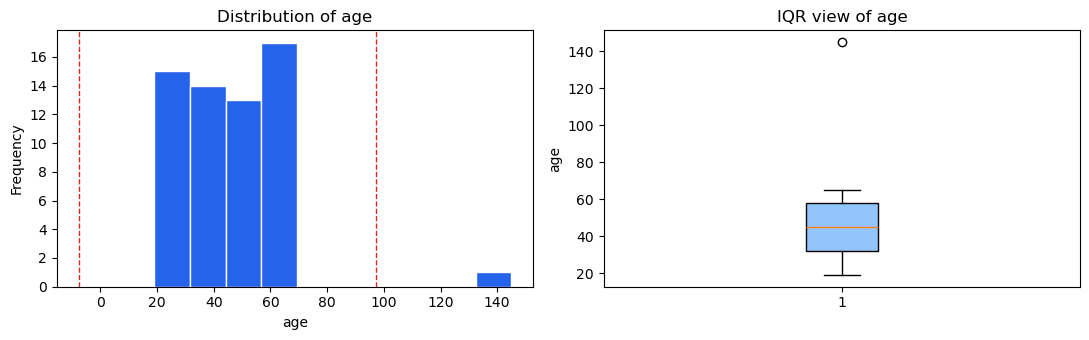

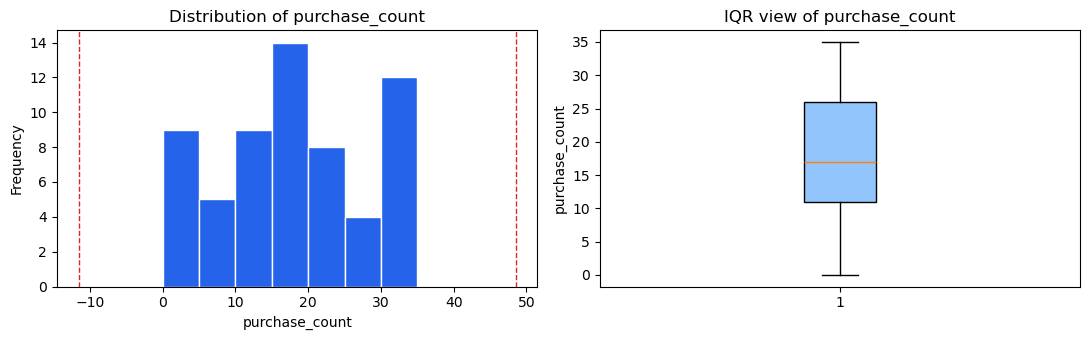

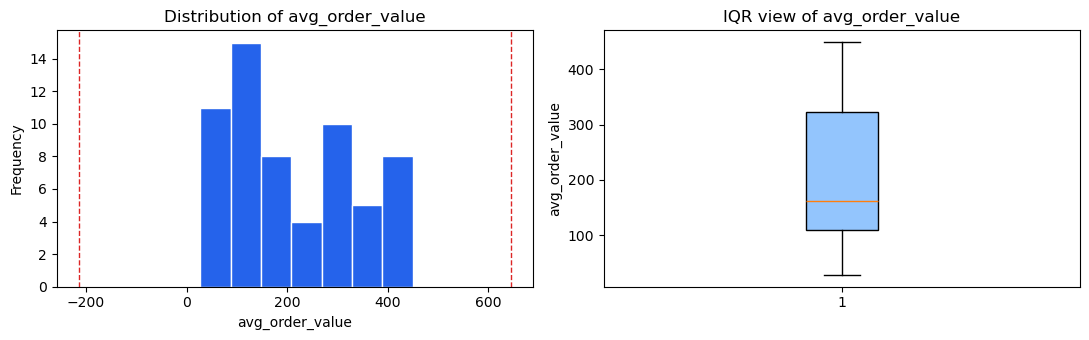

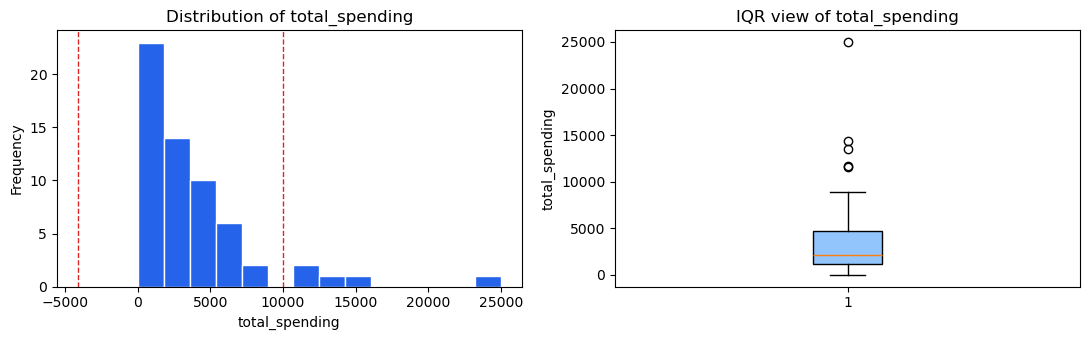

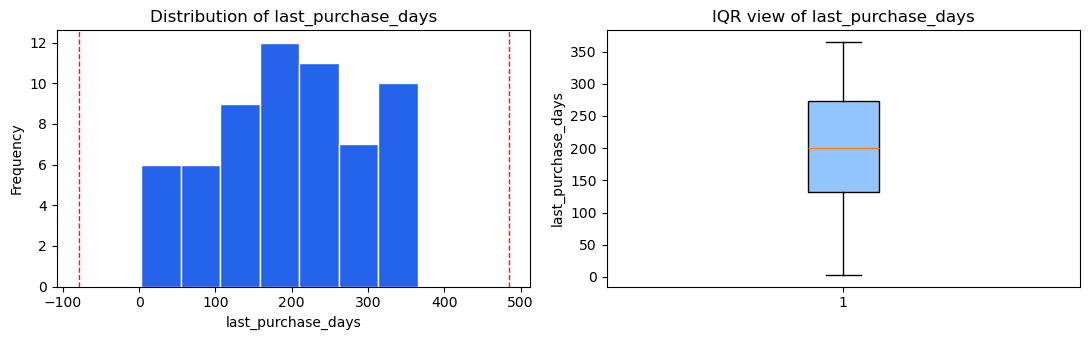

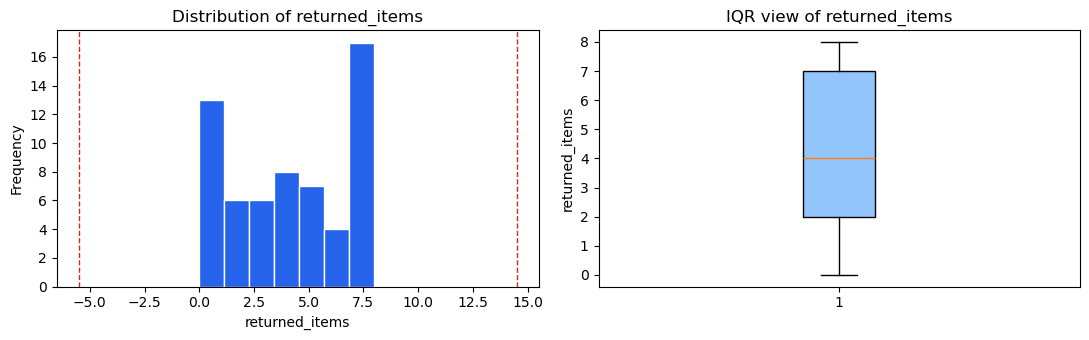

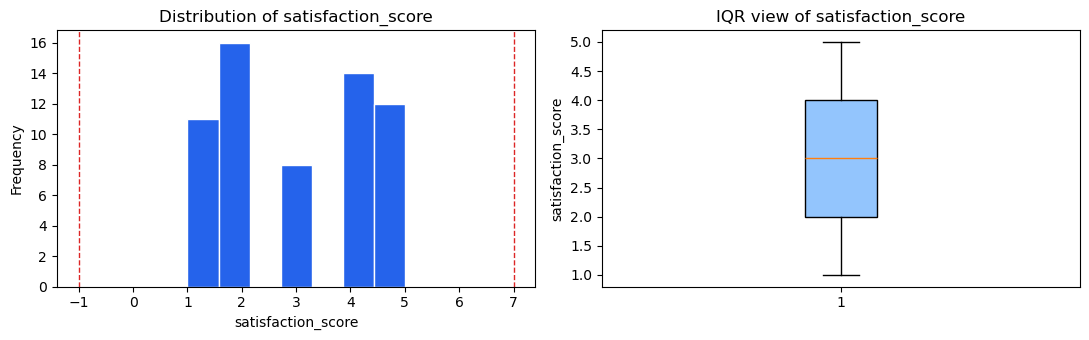


Assessment overview


,check,count
0,Rows with at least one missing value,2
1,Full duplicate rows (all occurrences),2
2,Rows with a duplicated customer_id,2
3,Invalid type values,0
4,Invalid logical values,8
5,Name–gender mismatches or unmapped names,38
6,Text whitespace issues,0
7,Normalized text duplicate groups,0
8,Possible text typo pairs,0
9,IQR outlier values,6



Column profile


,column,dtype,non_null_count,null_count,unique_count
0,customer_id,int64,61,0,60
1,first_name,object,61,0,12
2,gender,object,61,0,2
3,age,float64,60,1,35
4,city,object,61,0,8
5,province,object,61,0,8
6,signup_date,object,61,0,58
7,membership_tier,object,61,0,4
8,purchase_count,int64,61,0,30
9,avg_order_value,float64,61,0,60



Missing-value summary


...

,result
0,No issues found



IQR outlier summary


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
0,age,31.750,58.00,26.250,-7.6250,97.3750,1,1.64
1,purchase_count,11.000,26.00,15.000,-11.5000,48.5000,0,0.00
2,avg_order_value,108.190,323.32,215.130,-214.5050,646.0150,0,0.00
3,total_spending,1167.035,4692.15,3525.115,-4120.6375,9979.8225,5,8.20
4,last_purchase_days,132.000,273.00,141.000,-79.5000,484.5000,0,0.00
5,returned_items,2.000,7.00,5.000,-5.5000,14.5000,0,0.00
6,satisfaction_score,2.000,4.00,2.000,-1.0000,7.0000,0,0.00



IQR outlier rows


,excel_row,customer_id,column,value,lower_bound,upper_bound
0,11,1010,age,145.00,-7.6250,97.3750
1,10,1009,total_spending,11615.42,-4120.6375,9979.8225
2,13,1012,total_spending,11731.50,-4120.6375,9979.8225
3,31,1030,total_spending,25000.00,-4120.6375,9979.8225
4,45,1044,total_spending,14354.34,-4120.6375,9979.8225
5,58,1057,total_spending,13532.74,-4120.6375,9979.8225


In [62]:
basic_info = assess_basic_info(raw_df)
missing_summary, missing_rows = assess_missing_values(raw_df)
duplicate_rows, duplicate_customer_ids = assess_duplicates(raw_df)
type_summary, invalid_type_values = assess_data_types(raw_df)
invalid_logical_values = assess_logical_values(raw_df)
name_gender_issues = assess_name_gender_consistency(raw_df, normalized_name_gender_mapping)
location_issues = assess_location_consistency(raw_df)
whitespace_issues, normalized_text_groups, possible_typos = assess_text_consistency(raw_df)
outlier_summary, outlier_rows = assess_outliers(raw_df)

assessment_overview = pd.DataFrame([
    {"check": "Rows with at least one missing value", "count": len(missing_rows)},
    {"check": "Full duplicate rows (all occurrences)", "count": len(duplicate_rows)},
    {"check": "Rows with a duplicated customer_id", "count": len(duplicate_customer_ids)},
    {"check": "Invalid type values", "count": len(invalid_type_values)},
    {"check": "Invalid logical values", "count": len(invalid_logical_values)},
    {"check": "Name–gender mismatches or unmapped names", "count": len(name_gender_issues)},
    {"check": "Text whitespace issues", "count": len(whitespace_issues)},
    {"check": "Normalized text duplicate groups", "count": len(normalized_text_groups)},
    {"check": "Possible text typo pairs", "count": len(possible_typos)},
    {"check": "IQR outlier values", "count": len(outlier_rows)},
])
def show_assessment(title: str, table: pd.DataFrame) -> None:
    """Display a titled assessment table or a clear no-issues placeholder."""
    print(f"\n{title}")
    display(table if not table.empty else pd.DataFrame({"result": ["No issues found"]}))

show_assessment("Assessment overview", assessment_overview)
show_assessment("Column profile", basic_info)
show_assessment("Missing-value summary", missing_summary)
show_assessment("Rows containing missing values", missing_rows)
show_assessment("Full duplicate rows", duplicate_rows)
show_assessment("Duplicated customer IDs", duplicate_customer_ids)
show_assessment("Data-type summary", type_summary)
show_assessment("Invalid type values", invalid_type_values)
show_assessment("Invalid logical values", invalid_logical_values)
show_assessment("Name–gender consistency issues", name_gender_issues)
show_assessment("Text whitespace issues", whitespace_issues)
show_assessment("Normalized text groups", normalized_text_groups)
show_assessment("Possible text typos", possible_typos)
show_assessment("IQR outlier summary", outlier_summary)
show_assessment("IQR outlier rows", outlier_rows)

## 4. Cleaning step 1 — missing values and full duplicates

### Decisions

- **Missing `age`:** replace it with the median of plausible observed ages. The median is appropriate for numeric demographic data because it is less sensitive to extreme values than the mean. Implausible ages are excluded from the imputation statistic.
- **Missing `total_spending`:** recalculate it from `purchase_count * avg_order_value`. Because this is a derived field, a deterministic formula is more accurate than mean or median imputation.
- **Full duplicate row:** keep the first occurrence and remove the later identical record. Retaining both would double-weight the same customer in future analysis.

Every edit is captured in a row-level change log and displayed in the notebook.

In [63]:
step1_df = raw_df.copy()
step1_changes = []

numeric_age = pd.to_numeric(step1_df["age"], errors="coerce")
plausible_age_median = float(numeric_age[numeric_age.between(13, 100)].median())
missing_age_mask = numeric_age.isna()
for idx in step1_df.index[missing_age_mask]:
    step1_changes.append(change_record(
        stage="1 - missing values and duplicates", action="fill_missing_age",
        source_excel_row=idx + 2, customer_id=step1_df.at[idx, "customer_id"], column="age",
        old_value=step1_df.at[idx, "age"], new_value=plausible_age_median,
        rule="median of observed ages between 13 and 100",
        reason="Median imputation is robust for numeric demographic data.",
    ))
step1_df.loc[missing_age_mask, "age"] = plausible_age_median

missing_total_mask = step1_df["total_spending"].isna()
calculated_total = (step1_df["purchase_count"] * step1_df["avg_order_value"]).round(TOTAL_SPENDING_DECIMALS)
for idx in step1_df.index[missing_total_mask]:
    step1_changes.append(change_record(
        stage="1 - missing values and duplicates", action="fill_missing_total_spending",
        source_excel_row=idx + 2, customer_id=step1_df.at[idx, "customer_id"],
        column="total_spending", old_value=step1_df.at[idx, "total_spending"],
        new_value=calculated_total.at[idx], rule="purchase_count * avg_order_value",
        reason="The missing derived value was recalculated from its source columns.",
    ))
step1_df.loc[missing_total_mask, "total_spending"] = calculated_total[missing_total_mask]

duplicate_mask = step1_df.duplicated(keep="first")
for idx in step1_df.index[duplicate_mask]:
    step1_changes.append(change_record(
        stage="1 - missing values and duplicates", action="remove_full_duplicate_row",
        source_excel_row=idx + 2, customer_id=step1_df.at[idx, "customer_id"],
        column="all_columns", old_value="full duplicate row", new_value="removed",
        rule="keep the first full-row occurrence",
        reason="An identical record must not be counted twice in analysis.",
    ))
step1_df = step1_df.loc[~duplicate_mask].reset_index(drop=True)
step1_log = pd.DataFrame(step1_changes, columns=CHANGE_COLUMNS)

print(f"Step 1: {len(raw_df)} -> {len(step1_df)} rows; {len(step1_log)} logged changes.")
display(step1_log)

Step 1: 61 -> 60 rows; 3 logged changes.


,stage,action,source_excel_row,customer_id,column,old_value,new_value,rule,reason
0,1 - missing values and duplicates,fill_missing_age,21,1020,age,NaN,45.0,median of observed ages between 13 and 100,Median imputation is robust for numeric demographic data.
1,1 - missing values and duplicates,fill_missing_total_spending,41,1040,total_spending,NaN,1280.44,purchase_count * avg_order_value,The missing derived value was recalculated from its source columns.
2,1 - missing values and duplicates,remove_full_duplicate_row,62,1014,all_columns,full duplicate row,removed,keep the first full-row occurrence,An identical record must not be counted twice in analysis.


## 5. Cleaning step 2 — impossible returned-item counts

A customer cannot return more items than were purchased. Deleting the entire row would discard otherwise useful customer information, while replacing the value with a global statistic would ignore the row-specific upper limit. The selected rule caps `returned_items` at that row's `purchase_count`, which is the maximum logically valid value.

In [64]:
step2_df = step1_df.copy()
step2_changes = []
invalid_returns = step2_df["returned_items"] > step2_df["purchase_count"]

for idx in step2_df.index[invalid_returns]:
    old_value = step2_df.at[idx, "returned_items"]
    new_value = step2_df.at[idx, "purchase_count"]
    step2_changes.append(change_record(
        stage="2 - returned items", action="cap_returned_items_to_purchase_count",
        source_excel_row=idx + 2, customer_id=step2_df.at[idx, "customer_id"],
        column="returned_items", old_value=old_value, new_value=new_value,
        rule="returned_items <= purchase_count",
        reason="Returned items were capped at the maximum value allowed by the row's purchase count.",
    ))
    step2_df.at[idx, "returned_items"] = new_value

step2_log = pd.DataFrame(step2_changes, columns=CHANGE_COLUMNS)
print(f"Step 2: corrected {len(step2_log)} impossible returned-item values.")
display(step2_log)

Step 2: corrected 6 impossible returned-item values.


,stage,action,source_excel_row,customer_id,column,old_value,new_value,rule,reason
0,2 - returned items,cap_returned_items_to_purchase_count,9,1008,returned_items,8,3,returned_items <= purchase_count,Returned items were capped at the maximum value allowed by the row's purchase count.
1,2 - returned items,cap_returned_items_to_purchase_count,16,1015,returned_items,8,3,returned_items <= purchase_count,Returned items were capped at the maximum value allowed by the row's purchase count.
2,2 - returned items,cap_returned_items_to_purchase_count,25,1024,returned_items,2,0,returned_items <= purchase_count,Returned items were capped at the maximum value allowed by the row's purchase count.
3,2 - returned items,cap_returned_items_to_purchase_count,30,1029,returned_items,4,2,returned_items <= purchase_count,Returned items were capped at the maximum value allowed by the row's purchase count.
4,2 - returned items,cap_returned_items_to_purchase_count,38,1037,returned_items,7,1,returned_items <= purchase_count,Returned items were capped at the maximum value allowed by the row's purchase count.
5,2 - returned items,cap_returned_items_to_purchase_count,57,1056,returned_items,4,1,returned_items <= purchase_count,Returned items were capped at the maximum value allowed by the row's purchase count.


## 6. Cleaning step 3 — review `total_spending` outliers

IQR flags unusual values; it does not prove that they are errors. High-spending customers may be genuine and are important for customer-value analysis, so the pipeline does not delete, cap, or replace every outlier.

Each IQR outlier is checked against the business formula `purchase_count * avg_order_value` at three-decimal precision. Only an outlier that differs beyond the half-unit tolerance for three decimals is corrected. Formula-consistent outliers are retained and displayed separately for review.

In [65]:
step3_df = step2_df.copy()
spending = pd.to_numeric(step3_df["total_spending"], errors="coerce")
q1, q3 = spending.quantile([0.25, 0.75])
iqr = q3 - q1
spending_lower_bound = q1 - 1.5 * iqr
spending_upper_bound = q3 + 1.5 * iqr
spending_outlier_mask = (spending < spending_lower_bound) | (spending > spending_upper_bound)

spending_outliers = with_excel_row(
    step3_df.loc[spending_outlier_mask], "excel_row_after_step2"
)
spending_outliers["expected_total_spending"] = (
    spending_outliers["purchase_count"] * spending_outliers["avg_order_value"]
).round(TOTAL_SPENDING_DECIMALS)
spending_outliers["formula_difference"] = (
    spending_outliers["total_spending"].round(TOTAL_SPENDING_DECIMALS) - spending_outliers["expected_total_spending"]
).round(TOTAL_SPENDING_DECIMALS)
spending_outliers["iqr_lower_bound"] = round(spending_lower_bound, 2)
spending_outliers["iqr_upper_bound"] = round(spending_upper_bound, 2)

formula_error_mask = spending_outliers["formula_difference"].abs() > SPENDING_TOLERANCE
formula_errors = spending_outliers.loc[formula_error_mask].copy()
valid_spending_outliers = spending_outliers.loc[~formula_error_mask].copy()
step3_changes = []

for _, row in formula_errors.iterrows():
    idx = int(row["excel_row_after_step2"]) - 2
    old_value = step3_df.at[idx, "total_spending"]
    new_value = row["expected_total_spending"]
    step3_changes.append(change_record(
        stage="3 - total spending outliers", action="correct_total_spending_formula_error",
        source_excel_row=idx + 2, customer_id=row["customer_id"], column="total_spending",
        old_value=old_value, new_value=new_value, rule="purchase_count * avg_order_value",
        reason="The IQR outlier was a calculation error because it did not match the derived formula.",
    ))
    step3_df.at[idx, "total_spending"] = new_value

step3_log = pd.DataFrame(step3_changes, columns=CHANGE_COLUMNS)
print(f"IQR bounds: {spending_lower_bound:.2f} to {spending_upper_bound:.2f}")
print(f"Outliers reviewed: {len(spending_outliers)} | corrected: {len(step3_log)} | retained: {len(valid_spending_outliers)}")
display(step3_log)
display(format_decimal_columns_for_display(
    valid_spending_outliers[["customer_id", "total_spending", "expected_total_spending", "formula_difference"]],
    {"total_spending": TOTAL_SPENDING_DISPLAY_FORMAT,
     "expected_total_spending": TOTAL_SPENDING_DISPLAY_FORMAT,
     "formula_difference": TOTAL_SPENDING_DISPLAY_FORMAT},
))

IQR bounds: -4120.64 to 9979.82
Outliers reviewed: 5 | corrected: 1 | retained: 4


,stage,action,source_excel_row,customer_id,column,old_value,new_value,rule,reason
0,3 - total spending outliers,correct_total_spending_formula_error,31,1030,total_spending,25000.0,4079.14,purchase_count * avg_order_value,The IQR outlier was a calculation error because it did not match the derived formula.


,customer_id,total_spending,expected_total_spending,formula_difference
8,1009,11615.420,11615.420,0.000
11,1012,11731.500,11731.500,0.000
43,1044,14354.340,14354.340,0.000
56,1057,13532.740,13532.740,0.000


## 7. Cleaning step 4 — standardize `total_spending` precision

`total_spending` is a numeric derived field and must use three-decimal precision throughout the preprocessing pipeline. The values are rounded to three decimal places while remaining numeric, so future aggregation and modeling are unaffected. Because numeric columns do not store insignificant trailing zeros, the notebook also applies the display format `.3f` so values such as `2066.01` are shown as `2066.010`.

The function below is reusable for future datasets: if a value contains more than three decimal places, it is rounded and added to the audit log; values already within the target precision remain numerically unchanged.

In [66]:
def standardize_total_spending_precision(
    df: pd.DataFrame, decimals: int = TOTAL_SPENDING_DECIMALS
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Round ``total_spending`` to a fixed precision and audit numeric changes.

    Args:
        df: Dataset containing a numeric ``total_spending`` column.
        decimals: Number of decimal places to retain. Must be non-negative.

    Returns:
        A cleaned DataFrame with numeric rounded values and a normalized audit log
        containing only rows whose numeric values required rounding.

    Raises:
        ValueError: If ``decimals`` is negative.
    """
    if decimals < 0:
        raise ValueError("decimals must be non-negative")

    standardized_df = df.copy()
    original = pd.to_numeric(standardized_df["total_spending"], errors="coerce")
    standardized = original.round(decimals)
    changed_mask = original.notna() & original.ne(standardized)
    changes = []

    for idx in standardized_df.index[changed_mask]:
        changes.append(change_record(
            stage="4 - total spending precision",
            action="round_total_spending_to_three_decimals",
            source_excel_row=idx + 2,
            customer_id=standardized_df.at[idx, "customer_id"],
            column="total_spending",
            old_value=original.at[idx],
            new_value=standardized.at[idx],
            rule=f"round total_spending to {decimals} decimal places",
            reason="The derived spending field must use consistent three-decimal precision.",
        ))

    standardized_df["total_spending"] = standardized
    return standardized_df, pd.DataFrame(changes, columns=CHANGE_COLUMNS)

step4_df, step4_log = standardize_total_spending_precision(step3_df)
precision_summary = pd.DataFrame([{
    "rows_standardized": len(step4_df),
    "target_decimal_places": TOTAL_SPENDING_DECIMALS,
    "values_requiring_numeric_rounding": len(step4_log),
    "column_remains_numeric": bool(pd.api.types.is_numeric_dtype(step4_df["total_spending"])),
}])
display(precision_summary)
display(step4_log if not step4_log.empty else pd.DataFrame({"result": ["No values exceeded three-decimal precision."]}))
display(format_decimal_columns_for_display(
    step4_df[["customer_id", "purchase_count", "avg_order_value", "total_spending"]].head(10),
    {"total_spending": TOTAL_SPENDING_DISPLAY_FORMAT},
))

,rows_standardized,target_decimal_places,values_requiring_numeric_rounding,column_remains_numeric
0,60,3,0,True


,result
0,No values exceeded three-decimal precision.


,customer_id,purchase_count,avg_order_value,total_spending
0,1001,17,121.53,2066.010
1,1002,12,326.47,3917.640
2,1003,21,59.46,1248.660
3,1004,23,266.15,6121.450
4,1005,23,169.54,3899.420
5,1006,35,110.53,3868.550
6,1007,29,77.15,2237.350
7,1008,3,389.58,1168.740
8,1009,34,341.63,11615.420
9,1010,19,381.13,7241.470


## 8. Cleaning step 5 — implausible age

The dataset contains an implausible age (`145`). The row is retained because its other fields remain useful. The invalid value is replaced with the median calculated only from ages between 13 and 100, preventing the error itself from influencing the replacement statistic.

In [67]:
step5_df = step4_df.copy()
age = pd.to_numeric(step5_df["age"], errors="coerce")
valid_age_mask = age.between(13, 100)
invalid_age_mask = age.notna() & ~valid_age_mask
valid_age_median = float(age[valid_age_mask].median())
step5_changes = []

for idx in step5_df.index[invalid_age_mask]:
    step5_changes.append(change_record(
        stage="5 - invalid age", action="replace_invalid_age_with_valid_age_median",
        source_excel_row=idx + 2, customer_id=step5_df.at[idx, "customer_id"], column="age",
        old_value=step5_df.at[idx, "age"], new_value=valid_age_median,
        rule="median of ages between 13 and 100",
        reason="An implausible age was treated as a data-entry error while preserving the rest of the row.",
    ))
    step5_df.at[idx, "age"] = valid_age_median

step5_log = pd.DataFrame(step5_changes, columns=CHANGE_COLUMNS)
print(f"Step 5: corrected {len(step5_log)} invalid age value(s); valid-age median = {valid_age_median:g}.")
display(step5_log)
display(format_decimal_columns_for_display(
    step5_df,
    {"total_spending": TOTAL_SPENDING_DISPLAY_FORMAT},
))

Step 5: corrected 1 invalid age value(s); valid-age median = 45.


,stage,action,source_excel_row,customer_id,column,old_value,new_value,rule,reason
0,5 - invalid age,replace_invalid_age_with_valid_age_median,11,1010,age,145.0,45.0,median of ages between 13 and 100,An implausible age was treated as a data-entry error while preserving the rest of the row.


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.010,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.640,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.660,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.450,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.420,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,F,58.0,Mashhad,Khorasan,2022-01-26,Gold,35,110.53,3868.550,205,Cash,Android,Yes,5,2
6,1007,Reza,F,43.0,Rasht,Gilan,2025-09-09,VIP,29,77.15,2237.350,298,Cash,iPhone,Yes,2,5
7,1008,Reza,F,23.0,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.740,195,Online Wallet,iPhone,No,3,1
8,1009,Kimia,M,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.420,232,Card,Web,No,8,2
9,1010,Arash,F,45.0,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.470,276,Online Wallet,Android,No,7,1


## 9. Cleaning step 6 — standardize city and province

The city and province fields describe the same geographic location from two angles, so they are cleaned together. The notebook uses a reviewed reference for the cities present in this dataset and standardizes province aliases or incomplete names. For example, `Khorasan` is treated as an incomplete value for `Mashhad` and is standardized to `Khorasan Razavi`. `Gilan`, `Guilan`, and `Giluan` are treated as spelling variants of the same province and the project keeps the canonical spelling `Guilan`.

Unknown city or province values are not guessed. If a future dataset contains a new location outside the reference, this step raises an error so the reference can be reviewed explicitly before cleaning.

In [68]:
step6_df = step5_df.copy()
location_reference = build_location_reference()
location_standardization_review = assess_location_consistency(step6_df)

unrecognized_location_issues = location_standardization_review[
    location_standardization_review["issue"].isin(["unrecognized_city", "unrecognized_province"])
]
if not unrecognized_location_issues.empty:
    raise ValueError(
        "Review CITY_ALIASES, PROVINCE_ALIASES, and CITY_PROVINCE_REFERENCE before cleaning new locations."
    )

step6_changes = []
for idx, row in step6_df.iterrows():
    canonical_city = canonical_location_value(row["city"], CITY_ALIASES)
    expected_province = CITY_PROVINCE_REFERENCE[canonical_city]

    if row["city"] != canonical_city:
        step6_changes.append(change_record(
            stage="6 - city and province standardization",
            action="standardize_city_spelling",
            source_excel_row=idx + 2,
            customer_id=row["customer_id"],
            column="city",
            old_value=row["city"],
            new_value=canonical_city,
            rule="CITY_ALIASES maps normalized city text to canonical spelling",
            reason="The city value was a recognized spelling or casing variant.",
        ))
        step6_df.at[idx, "city"] = canonical_city

    if row["province"] != expected_province:
        step6_changes.append(change_record(
            stage="6 - city and province standardization",
            action="standardize_province_from_city_reference",
            source_excel_row=idx + 2,
            customer_id=row["customer_id"],
            column="province",
            old_value=row["province"],
            new_value=expected_province,
            rule="CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province",
            reason="The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city.",
        ))
        step6_df.at[idx, "province"] = expected_province

step6_log = pd.DataFrame(step6_changes, columns=CHANGE_COLUMNS)
print(f"Step 6: corrected {len(step6_log)} city/province value(s).")
display(location_reference)
display(location_standardization_review if not location_standardization_review.empty else pd.DataFrame({"result": ["No location issues found"]}))
display(step6_log if not step6_log.empty else pd.DataFrame({"result": ["No city/province values required standardization"]}))
display(format_decimal_columns_for_display(
    step6_df,
    {"total_spending": TOTAL_SPENDING_DISPLAY_FORMAT},
))

Step 6: corrected 16 city/province value(s).


,city,province
0,Ahvaz,Khuzestan
1,Isfahan,Isfahan
2,Karaj,Alborz
3,Mashhad,Khorasan Razavi
4,Rasht,Guilan
5,Shiraz,Fars
6,Tabriz,East Azerbaijan
7,Tehran,Tehran


,excel_row,customer_id,column,value,suggested_value,issue,expected
0,5,1004,province,Khorasan,Khorasan Razavi,province_alias_or_spelling_variant,canonical province spelling/full name
1,7,1006,province,Khorasan,Khorasan Razavi,province_alias_or_spelling_variant,canonical province spelling/full name
2,8,1007,province,Gilan,Guilan,province_alias_or_spelling_variant,canonical province spelling/full name
3,9,1008,province,Gilan,Guilan,province_alias_or_spelling_variant,canonical province spelling/full name
4,13,1012,province,Khorasan,Khorasan Razavi,province_alias_or_spelling_variant,canonical province spelling/full name
5,23,1022,province,Khorasan,Khorasan Razavi,province_alias_or_spelling_variant,canonical province spelling/full name
6,24,1023,province,Khorasan,Khorasan Razavi,province_alias_or_spelling_variant,canonical province spelling/full name
7,26,1025,province,Khorasan,Khorasan Razavi,province_alias_or_spelling_variant,canonical province spelling/full name
8,31,1030,province,Khorasan,Khorasan Razavi,province_alias_or_spelling_variant,canonical province spelling/full name
9,39,1038,province,Khorasan,Khorasan Razavi,province_alias_or_spelling_variant,canonical province spelling/full name


,stage,action,source_excel_row,customer_id,column,old_value,new_value,rule,reason
0,6 - city and province standardization,standardize_province_from_city_reference,5,1004,province,Khorasan,Khorasan Razavi,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."
1,6 - city and province standardization,standardize_province_from_city_reference,7,1006,province,Khorasan,Khorasan Razavi,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."
2,6 - city and province standardization,standardize_province_from_city_reference,8,1007,province,Gilan,Guilan,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."
3,6 - city and province standardization,standardize_province_from_city_reference,9,1008,province,Gilan,Guilan,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."
4,6 - city and province standardization,standardize_province_from_city_reference,13,1012,province,Khorasan,Khorasan Razavi,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."
5,6 - city and province standardization,standardize_province_from_city_reference,23,1022,province,Khorasan,Khorasan Razavi,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."
6,6 - city and province standardization,standardize_province_from_city_reference,24,1023,province,Khorasan,Khorasan Razavi,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."
7,6 - city and province standardization,standardize_province_from_city_reference,26,1025,province,Khorasan,Khorasan Razavi,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."
8,6 - city and province standardization,standardize_province_from_city_reference,31,1030,province,Khorasan,Khorasan Razavi,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."
9,6 - city and province standardization,standardize_province_from_city_reference,39,1038,province,Khorasan,Khorasan Razavi,CITY_PROVINCE_REFERENCE maps each reviewed city to its canonical province,"The province value was an alias, spelling variant, incomplete name, or inconsistent with the row's city."


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.010,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.640,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.660,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan Razavi,2021-11-08,Gold,23,266.15,6121.450,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.420,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,F,58.0,Mashhad,Khorasan Razavi,2022-01-26,Gold,35,110.53,3868.550,205,Cash,Android,Yes,5,2
6,1007,Reza,F,43.0,Rasht,Guilan,2025-09-09,VIP,29,77.15,2237.350,298,Cash,iPhone,Yes,2,5
7,1008,Reza,F,23.0,Rasht,Guilan,2024-10-03,VIP,3,389.58,1168.740,195,Online Wallet,iPhone,No,3,1
8,1009,Kimia,M,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.420,232,Card,Web,No,8,2
9,1010,Arash,F,45.0,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.470,276,Online Wallet,Android,No,7,1


## 10. Cleaning step 7 — harmonize names and gender

The dataset's 12 unique names are mapped explicitly in `clean_data_code/name_gender_mapping.json`: `Ali`, `Amir`, `Arash`, `Parsa`, `Reza`, and `Sina` map to `M`; `Kimia`, `Maryam`, `Mina`, `Neda`, `Sara`, and `Zahra` map to `F`. The reference is kept outside the code so it can be reviewed and versioned independently.

Names are compared after trimming/collapsing whitespace and case-folding; the stored `first_name` value is not changed. Every current input name must be present in the JSON. An unknown future name raises an error instead of receiving a guessed gender. After removal of the full duplicate, 38 of the current 60 rows have a conflicting `gender`; these rows are displayed before correction and recorded individually in the common audit log.

In [69]:
gender_mismatch_review = assess_name_gender_consistency(
    step6_df, normalized_name_gender_mapping
)
unmapped_after_cleaning = gender_mismatch_review.loc[
    gender_mismatch_review["issue"].eq("name_missing_from_mapping"), "first_name"
].dropna().unique().tolist()
if unmapped_after_cleaning:
    raise ValueError(
        f"Update {NAME_GENDER_MAPPING_FILENAME} for unmapped names: {unmapped_after_cleaning}"
    )

step7_df = step6_df.copy()
normalized_step7_names = step7_df["first_name"].map(normalize_text)
expected_step7_gender = normalized_step7_names.map(normalized_name_gender_mapping)
current_step7_gender = step7_df["gender"].astype("string").str.strip().str.upper()
gender_mismatch_mask = current_step7_gender.ne(expected_step7_gender)
step7_changes = []

for idx in step7_df.index[gender_mismatch_mask]:
    expected_value = expected_step7_gender.at[idx]
    step7_changes.append(change_record(
        stage="7 - name and gender consistency",
        action="correct_gender_from_name_mapping",
        source_excel_row=idx + 2,
        customer_id=step7_df.at[idx, "customer_id"],
        column="gender",
        old_value=step7_df.at[idx, "gender"],
        new_value=expected_value,
        rule=f"{NAME_GENDER_MAPPING_FILENAME}: normalized first_name maps to gender",
        reason="The recorded gender conflicted with the reviewed name-gender reference.",
    ))
    step7_df.at[idx, "gender"] = expected_value

step7_log = pd.DataFrame(step7_changes, columns=CHANGE_COLUMNS)
print(f"Step 7: corrected {len(step7_log)} name-gender mismatch(es).")
display(gender_mismatch_review)
display(step7_log)
print(f"Step 7 dataset: {len(step7_df)} rows x {len(step7_df.columns)} columns")
display(format_decimal_columns_for_display(
    step7_df,
    {"total_spending": TOTAL_SPENDING_DISPLAY_FORMAT},
))

Step 7: corrected 38 name-gender mismatch(es).


,excel_row,customer_id,first_name,gender,expected_gender,issue
0,2,1001,Reza,F,M,name_gender_mismatch
2,4,1003,Parsa,F,M,name_gender_mismatch
3,5,1004,Sina,F,M,name_gender_mismatch
4,6,1005,Kimia,M,F,name_gender_mismatch
5,7,1006,Amir,F,M,name_gender_mismatch
6,8,1007,Reza,F,M,name_gender_mismatch
7,9,1008,Reza,F,M,name_gender_mismatch
8,10,1009,Kimia,M,F,name_gender_mismatch
9,11,1010,Arash,F,M,name_gender_mismatch
11,13,1012,Arash,F,M,name_gender_mismatch


,stage,action,source_excel_row,customer_id,column,old_value,new_value,rule,reason
0,7 - name and gender consistency,correct_gender_from_name_mapping,2,1001,gender,F,M,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.
1,7 - name and gender consistency,correct_gender_from_name_mapping,4,1003,gender,F,M,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.
2,7 - name and gender consistency,correct_gender_from_name_mapping,5,1004,gender,F,M,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.
3,7 - name and gender consistency,correct_gender_from_name_mapping,6,1005,gender,M,F,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.
4,7 - name and gender consistency,correct_gender_from_name_mapping,7,1006,gender,F,M,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.
5,7 - name and gender consistency,correct_gender_from_name_mapping,8,1007,gender,F,M,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.
6,7 - name and gender consistency,correct_gender_from_name_mapping,9,1008,gender,F,M,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.
7,7 - name and gender consistency,correct_gender_from_name_mapping,10,1009,gender,M,F,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.
8,7 - name and gender consistency,correct_gender_from_name_mapping,11,1010,gender,F,M,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.
9,7 - name and gender consistency,correct_gender_from_name_mapping,13,1012,gender,F,M,name_gender_mapping.json: normalized first_name maps to gender,The recorded gender conflicted with the reviewed name-gender reference.


Step 7 dataset: 60 rows x 17 columns


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.010,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.640,3,Card,Web,No,5,3
2,1003,Parsa,M,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.660,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58.0,Mashhad,Khorasan Razavi,2021-11-08,Gold,23,266.15,6121.450,40,Card,Android,No,4,4
4,1005,Kimia,F,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.420,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,M,58.0,Mashhad,Khorasan Razavi,2022-01-26,Gold,35,110.53,3868.550,205,Cash,Android,Yes,5,2
6,1007,Reza,M,43.0,Rasht,Guilan,2025-09-09,VIP,29,77.15,2237.350,298,Cash,iPhone,Yes,2,5
7,1008,Reza,M,23.0,Rasht,Guilan,2024-10-03,VIP,3,389.58,1168.740,195,Online Wallet,iPhone,No,3,1
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.420,232,Card,Web,No,8,2
9,1010,Arash,M,45.0,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.470,276,Online Wallet,Android,No,7,1


## 11. Cleaning step 8 - convert date and encode gender

The raw `signup_date` column is loaded from Excel as `object`/string, so it is converted with `pd.to_datetime` and stored as pandas `datetime64`. Invalid or future dates stop the pipeline instead of being silently changed.

After name-gender correction, `gender` has only two valid values. It is therefore encoded as a binary integer feature with an explicit project rule: `F -> 0` and `M -> 1`. The mapping table is displayed in the notebook so downstream analysis can interpret the encoded column correctly.

In [70]:
step8_df = step7_df.copy()
step8_changes = []

parsed_signup = pd.to_datetime(step8_df["signup_date"], errors="coerce")
invalid_signup_mask = parsed_signup.isna() & step8_df["signup_date"].notna()
if invalid_signup_mask.any():
    invalid_dates = with_excel_row(
        step8_df.loc[invalid_signup_mask, ["customer_id", "signup_date"]]
    )
    display(invalid_dates)
    raise ValueError("Fix invalid signup_date values before converting the column type.")

future_signup_mask = parsed_signup.notna() & (parsed_signup.dt.date > date.today())
if future_signup_mask.any():
    future_dates = with_excel_row(
        step8_df.loc[future_signup_mask, ["customer_id", "signup_date"]]
    )
    display(future_dates)
    raise ValueError("Fix future signup_date values before finalizing the cleaned dataset.")

for idx in step8_df.index:
    old_value = step8_df.at[idx, "signup_date"]
    new_value = parsed_signup.at[idx].date().isoformat()
    step8_changes.append(change_record(
        stage="8 - date type and binary gender encoding",
        action="convert_signup_date_to_datetime",
        source_excel_row=idx + 2,
        customer_id=step8_df.at[idx, "customer_id"],
        column="signup_date",
        old_value=old_value,
        new_value=new_value,
        rule="pd.to_datetime(signup_date) stored as datetime64",
        reason="The date field must be typed as date-compatible datetime data, not object/string.",
    ))
step8_df["signup_date"] = parsed_signup.dt.normalize()

normalized_gender_for_encoding = step8_df["gender"].astype("string").str.strip().str.upper()
unencodable_gender = sorted(
    normalized_gender_for_encoding.loc[~normalized_gender_for_encoding.isin(ALLOWED_GENDER_CODES)]
    .dropna().unique().tolist()
)
if unencodable_gender:
    raise ValueError(f"Gender values cannot be encoded with {GENDER_BINARY_MAPPING}: {unencodable_gender}")

encoded_gender = normalized_gender_for_encoding.map(GENDER_BINARY_MAPPING).astype("int64")
for idx in step8_df.index:
    step8_changes.append(change_record(
        stage="8 - date type and binary gender encoding",
        action="encode_gender_binary",
        source_excel_row=idx + 2,
        customer_id=step8_df.at[idx, "customer_id"],
        column="gender",
        old_value=step8_df.at[idx, "gender"],
        new_value=int(encoded_gender.at[idx]),
        rule="F -> 0, M -> 1",
        reason="The final gender feature has two categories and is encoded explicitly for analysis/modeling.",
    ))
step8_df["gender"] = encoded_gender

final_df = step8_df.copy()
step8_log = pd.DataFrame(step8_changes, columns=CHANGE_COLUMNS)
gender_binary_reference = pd.DataFrame(
    [{"gender_label": label, "encoded_value": code} for label, code in GENDER_BINARY_MAPPING.items()]
).sort_values("encoded_value", ignore_index=True)
type_conversion_summary = pd.DataFrame([
    {
        "column": "signup_date",
        "final_dtype": str(final_df["signup_date"].dtype),
        "valid_values": int(final_df["signup_date"].notna().sum()),
        "rule": "object/string -> datetime64",
    },
    {
        "column": "gender",
        "final_dtype": str(final_df["gender"].dtype),
        "valid_values": int(final_df["gender"].isin(BINARY_GENDER_CODES).sum()),
        "rule": "F -> 0, M -> 1",
    },
])

print(f"Step 8: converted signup_date dtype and encoded {len(final_df)} gender value(s).")
display(gender_binary_reference)
display(type_conversion_summary)
display(step8_log)
print(f"Final cleaned dataset: {len(final_df)} rows x {len(final_df.columns)} columns")
display(format_decimal_columns_for_display(
    final_df,
    {"total_spending": TOTAL_SPENDING_DISPLAY_FORMAT},
))

Step 8: converted signup_date dtype and encoded 60 gender value(s).


,gender_label,encoded_value
0,F,0
1,M,1


,column,final_dtype,valid_values,rule
0,signup_date,datetime64[ns],60,object/string -> datetime64
1,gender,int64,60,"F -> 0, M -> 1"


,stage,action,source_excel_row,customer_id,column,old_value,new_value,rule,reason
0,8 - date type and binary gender encoding,convert_signup_date_to_datetime,2,1001,signup_date,2025-02-19,2025-02-19,pd.to_datetime(signup_date) stored as datetime64,"The date field must be typed as date-compatible datetime data, not object/string."
1,8 - date type and binary gender encoding,convert_signup_date_to_datetime,3,1002,signup_date,2022-08-19,2022-08-19,pd.to_datetime(signup_date) stored as datetime64,"The date field must be typed as date-compatible datetime data, not object/string."
2,8 - date type and binary gender encoding,convert_signup_date_to_datetime,4,1003,signup_date,2023-06-20,2023-06-20,pd.to_datetime(signup_date) stored as datetime64,"The date field must be typed as date-compatible datetime data, not object/string."
3,8 - date type and binary gender encoding,convert_signup_date_to_datetime,5,1004,signup_date,2021-11-08,2021-11-08,pd.to_datetime(signup_date) stored as datetime64,"The date field must be typed as date-compatible datetime data, not object/string."
4,8 - date type and binary gender encoding,convert_signup_date_to_datetime,6,1005,signup_date,2021-10-21,2021-10-21,pd.to_datetime(signup_date) stored as datetime64,"The date field must be typed as date-compatible datetime data, not object/string."
...,...,...,...,...,...,...,...,...,...
115,8 - date type and binary gender encoding,encode_gender_binary,57,1056,gender,F,0,"F -> 0, M -> 1",The final gender feature has two categories and is encoded explicitly for analysis/modeling.
116,8 - date type and binary gender encoding,encode_gender_binary,58,1057,gender,F,0,"F -> 0, M -> 1",The final gender feature has two categories and is encoded explicitly for analysis/modeling.
117,8 - date type and binary gender encoding,encode_gender_binary,59,1058,gender,M,1,"F -> 0, M -> 1",The final gender feature has two categories and is encoded explicitly for analysis/modeling.
118,8 - date type and binary gender encoding,encode_gender_binary,60,1059,gender,M,1,"F -> 0, M -> 1",The final gender feature has two categories and is encoded explicitly for analysis/modeling.


Final cleaned dataset: 60 rows x 17 columns


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,1,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.010,16,Card,Android,Yes,3,5
1,1002,Sina,1,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.640,3,Card,Web,No,5,3
2,1003,Parsa,1,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.660,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,1,58.0,Mashhad,Khorasan Razavi,2021-11-08,Gold,23,266.15,6121.450,40,Card,Android,No,4,4
4,1005,Kimia,0,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.420,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,1,58.0,Mashhad,Khorasan Razavi,2022-01-26,Gold,35,110.53,3868.550,205,Cash,Android,Yes,5,2
6,1007,Reza,1,43.0,Rasht,Guilan,2025-09-09,VIP,29,77.15,2237.350,298,Cash,iPhone,Yes,2,5
7,1008,Reza,1,23.0,Rasht,Guilan,2024-10-03,VIP,3,389.58,1168.740,195,Online Wallet,iPhone,No,3,1
8,1009,Kimia,0,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.420,232,Card,Web,No,8,2
9,1010,Arash,1,45.0,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.470,276,Online Wallet,Android,No,7,1


## 12. Consolidated audit trail

The stage-specific logs remain available as notebook variables. They are also combined into one consistent audit table so every change can be filtered by stage, customer, column, rule, or action.

In [71]:
all_changes = pd.concat(
    [step1_log, step2_log, step3_log, step4_log, step5_log, step6_log, step7_log, step8_log], ignore_index=True
).reindex(columns=CHANGE_COLUMNS)
change_summary = (
    all_changes.groupby(["stage", "action"], dropna=False)
    .size().rename("rows_changed").reset_index()
)
display(change_summary)
display(all_changes)

,stage,action,rows_changed
0,1 - missing values and duplicates,fill_missing_age,1
1,1 - missing values and duplicates,fill_missing_total_spending,1
2,1 - missing values and duplicates,remove_full_duplicate_row,1
3,2 - returned items,cap_returned_items_to_purchase_count,6
4,3 - total spending outliers,correct_total_spending_formula_error,1
5,5 - invalid age,replace_invalid_age_with_valid_age_median,1
6,6 - city and province standardization,standardize_province_from_city_reference,16
7,7 - name and gender consistency,correct_gender_from_name_mapping,38
8,8 - date type and binary gender encoding,convert_signup_date_to_datetime,60
9,8 - date type and binary gender encoding,encode_gender_binary,60


,stage,action,source_excel_row,customer_id,column,old_value,new_value,rule,reason
0,1 - missing values and duplicates,fill_missing_age,21,1020,age,NaN,45.0,median of observed ages between 13 and 100,Median imputation is robust for numeric demographic data.
1,1 - missing values and duplicates,fill_missing_total_spending,41,1040,total_spending,NaN,1280.44,purchase_count * avg_order_value,The missing derived value was recalculated from its source columns.
2,1 - missing values and duplicates,remove_full_duplicate_row,62,1014,all_columns,full duplicate row,removed,keep the first full-row occurrence,An identical record must not be counted twice in analysis.
3,2 - returned items,cap_returned_items_to_purchase_count,9,1008,returned_items,8,3,returned_items <= purchase_count,Returned items were capped at the maximum value allowed by the row's purchase count.
4,2 - returned items,cap_returned_items_to_purchase_count,16,1015,returned_items,8,3,returned_items <= purchase_count,Returned items were capped at the maximum value allowed by the row's purchase count.
...,...,...,...,...,...,...,...,...,...
180,8 - date type and binary gender encoding,encode_gender_binary,57,1056,gender,F,0,"F -> 0, M -> 1",The final gender feature has two categories and is encoded explicitly for analysis/modeling.
181,8 - date type and binary gender encoding,encode_gender_binary,58,1057,gender,F,0,"F -> 0, M -> 1",The final gender feature has two categories and is encoded explicitly for analysis/modeling.
182,8 - date type and binary gender encoding,encode_gender_binary,59,1058,gender,M,1,"F -> 0, M -> 1",The final gender feature has two categories and is encoded explicitly for analysis/modeling.
183,8 - date type and binary gender encoding,encode_gender_binary,60,1059,gender,M,1,"F -> 0, M -> 1",The final gender feature has two categories and is encoded explicitly for analysis/modeling.


## 13. Final validation

A cleaning pipeline is complete only when its assumptions are tested after transformation. The checks below confirm the final dataset's schema, missing values, uniqueness, business rules, formula consistency, date validity, and categorical domains. The final assertion stops the notebook if any required check fails.

In [72]:
validated_final = final_df.copy()
final_age = pd.to_numeric(validated_final["age"], errors="coerce")
expected_spending = (
    pd.to_numeric(validated_final["purchase_count"], errors="coerce")
    * pd.to_numeric(validated_final["avg_order_value"], errors="coerce")
).round(TOTAL_SPENDING_DECIMALS)
final_total_spending = pd.to_numeric(validated_final["total_spending"], errors="coerce")
actual_spending = final_total_spending.round(TOTAL_SPENDING_DECIMALS)
parsed_signup = pd.to_datetime(validated_final["signup_date"], errors="coerce")
final_normalized_names = validated_final["first_name"].map(normalize_text)
final_expected_gender_label = final_normalized_names.map(normalized_name_gender_mapping)
final_expected_gender_code = final_expected_gender_label.map(GENDER_BINARY_MAPPING)
final_current_gender_code = pd.to_numeric(validated_final["gender"], errors="coerce")
final_location_issues = assess_location_consistency(validated_final)
final_allowed_values = {**ALLOWED_VALUES, "gender": BINARY_GENDER_CODES}
category_violations = sum(
    int((validated_final[column].notna() & ~validated_final[column].isin(allowed)).sum())
    for column, allowed in final_allowed_values.items()
)

validation_results = [
    ("Expected columns and order", list(validated_final.columns) == list(EXPECTED_SCHEMA)),
    ("No missing values", int(validated_final.isna().sum().sum()) == 0),
    ("No full duplicate rows", int(validated_final.duplicated().sum()) == 0),
    ("customer_id is unique", int(validated_final["customer_id"].duplicated().sum()) == 0),
    ("Age is between 13 and 100", bool(final_age.between(13, 100).all())),
    ("returned_items <= purchase_count",
     bool((validated_final["returned_items"] <= validated_final["purchase_count"]).all())),
    ("total_spending values use at most three decimal places",
     bool(((final_total_spending - actual_spending).abs() <= SPENDING_TOLERANCE).all())),
    ("total_spending display format shows exactly three decimal places",
     TOTAL_SPENDING_DISPLAY_FORMAT.format(1.2) == "1.200"),
    ("total_spending matches the derived formula",
     bool(((actual_spending - expected_spending).abs() <= SPENDING_TOLERANCE).all())),
    ("signup_date dtype is datetime64",
     bool(pd.api.types.is_datetime64_any_dtype(validated_final["signup_date"]))),
    ("signup_date values are valid and not in the future",
     bool(parsed_signup.notna().all() and (parsed_signup.dt.date <= date.today()).all())),
    ("City/province values match the reviewed location reference", final_location_issues.empty),
    ("Every first_name is covered by the JSON mapping", bool(final_expected_gender_label.notna().all())),
    ("gender uses binary integer codes F=0 and M=1",
     bool(pd.api.types.is_integer_dtype(validated_final["gender"])
          and validated_final["gender"].isin(BINARY_GENDER_CODES).all())),
    ("gender binary code matches the JSON name mapping",
     bool(final_current_gender_code.eq(final_expected_gender_code).all())),
    ("Categorical values are within allowed domains", category_violations == 0),
]
validation_summary = pd.DataFrame(validation_results, columns=["check", "passed"])
validation_summary["status"] = validation_summary["passed"].map({True: "PASS", False: "FAIL"})
display(validation_summary[["check", "status"]])

failed_checks = validation_summary.loc[~validation_summary["passed"], "check"].tolist()
assert not failed_checks, f"Final validation failed: {failed_checks}"
print("All final validation checks passed.")

,check,status
0,Expected columns and order,PASS
1,No missing values,PASS
2,No full duplicate rows,PASS
3,customer_id is unique,PASS
4,Age is between 13 and 100,PASS
5,returned_items <= purchase_count,PASS
6,total_spending values use at most three decimal places,PASS
7,total_spending display format shows exactly three decimal places,PASS
8,total_spending matches the derived formula,PASS
9,signup_date dtype is datetime64,PASS


All final validation checks passed.


## 14. Export cleaned dataset

After final validation passes, the cleaned dataset is written to `data/cleaned_dataset_FatemehDehghan224.xlsx`. The raw workbook remains unchanged.


In [ ]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

try:
    with pd.ExcelWriter(
        CLEANED_DATA_PATH,
        engine="openpyxl",
        datetime_format="yyyy-mm-dd",
        date_format="yyyy-mm-dd",
    ) as writer:
        validated_final.to_excel(writer, sheet_name="customers", index=False)
except PermissionError as exc:
    raise PermissionError(
        f"Close {CLEANED_DATA_PATH.name} if it is open, then rerun this cell."
    ) from exc

exported_check = pd.read_excel(CLEANED_DATA_PATH, sheet_name="customers")
assert list(exported_check.columns) == list(validated_final.columns), "Exported workbook columns do not match final_df."
assert exported_check.shape == validated_final.shape, "Exported workbook shape does not match final_df."

cleaned_export_summary = pd.DataFrame([
    {
        "output_file": str(CLEANED_DATA_PATH.relative_to(PROJECT_ROOT)),
        "sheet_name": "customers",
        "rows": len(validated_final),
        "columns": len(validated_final.columns),
        "status": "written after final validation",
    }
])
print(f"Cleaned dataset written: {CLEANED_DATA_PATH.relative_to(PROJECT_ROOT)}")
display(cleaned_export_summary)


## 15. Before/after quality summary and notebook results

The final section provides presentation-ready evidence of the pipeline's effect and lists the main results available after a complete run. Valid high-spending outliers remain in the final data because they pass the underlying formula check.

In [73]:
def gender_mismatch_count(df: pd.DataFrame) -> int:
    """Compare gender with the name reference before or after binary encoding."""
    expected_label = df["first_name"].map(normalize_text).map(normalized_name_gender_mapping)
    current = df["gender"]
    if pd.api.types.is_numeric_dtype(current):
        expected = expected_label.map(GENDER_BINARY_MAPPING)
        actual = pd.to_numeric(current, errors="coerce")
    else:
        expected = expected_label
        actual = current.astype("string").str.strip().str.upper()
    return int((expected.notna() & actual.ne(expected)).sum())

def quality_snapshot(df: pd.DataFrame) -> dict[str, int]:
    """Return the key quality-issue counts used in the before/after comparison.

    The snapshot covers row count, missing values, duplicate records and identifiers,
    invalid ages, impossible return counts, location standardization issues, date dtype,
    binary gender encoding, spending formula mismatches, and name-gender consistency.
    """
    age = pd.to_numeric(df["age"], errors="coerce")
    expected = (pd.to_numeric(df["purchase_count"], errors="coerce")
                * pd.to_numeric(df["avg_order_value"], errors="coerce")).round(TOTAL_SPENDING_DECIMALS)
    actual = pd.to_numeric(df["total_spending"], errors="coerce").round(TOTAL_SPENDING_DECIMALS)
    expected_gender = df["first_name"].map(normalize_text).map(normalized_name_gender_mapping)
    current_gender_code = pd.to_numeric(df["gender"], errors="coerce")
    location_issues = assess_location_consistency(df)
    parsed_dates = pd.to_datetime(df["signup_date"], errors="coerce")
    return {
        "rows": len(df),
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows_to_remove": int(df.duplicated(keep="first").sum()),
        "duplicate_customer_ids_to_remove": int(df["customer_id"].duplicated(keep="first").sum()),
        "invalid_ages": int((age.notna() & ~age.between(13, 100)).sum()),
        "impossible_return_counts": int((df["returned_items"] > df["purchase_count"]).sum()),
        "city_province_standardization_issues": len(location_issues),
        "invalid_signup_dates": int((parsed_dates.isna() & df["signup_date"].notna()).sum()),
        "signup_date_not_datetime_dtype": int(not pd.api.types.is_datetime64_any_dtype(df["signup_date"])),
        "unmapped_first_names": int(expected_gender.isna().sum()),
        "name_gender_mismatches": gender_mismatch_count(df),
        "non_binary_gender_values": int((current_gender_code.isna() | ~current_gender_code.isin(BINARY_GENDER_CODES)).sum()),
        "spending_formula_mismatches": int((actual.notna() & expected.notna()
                                              & ((actual - expected).abs() > SPENDING_TOLERANCE)).sum()),
    }

before_after = pd.DataFrame(
    {"Before cleaning": quality_snapshot(raw_df),
     "After cleaning": quality_snapshot(validated_final)}
).rename_axis("quality_metric").reset_index()
display(before_after)

notebook_results = pd.DataFrame([
    {"result": "Final cleaned dataset", "variable": "final_df"},
    {"result": "Combined change log", "variable": "all_changes"},
    {"result": "Final validation summary", "variable": "validation_summary"},
    {"result": "Cleaned Excel export", "variable": "cleaned_export_summary"},
    {"result": "Before/after quality summary", "variable": "before_after"},
    {"result": "Total spending precision summary", "variable": "precision_summary"},
    {"result": "Type conversion summary", "variable": "type_conversion_summary"},
    {"result": "Gender binary mapping", "variable": "gender_binary_reference"},
    {"result": "Name-gender JSON reference", "variable": "name_gender_reference"},
    {"result": "Location reference", "variable": "location_reference"},
    {"result": "Location issues before standardization", "variable": "location_standardization_review"},
    {"result": "Name-gender mismatches before correction", "variable": "gender_mismatch_review"},
    {"result": "Valid spending outliers retained", "variable": "valid_spending_outliers"},
])
display(notebook_results)

,quality_metric,Before cleaning,After cleaning
0,rows,61,60
1,missing_values,2,0
2,duplicate_rows_to_remove,1,0
3,duplicate_customer_ids_to_remove,1,0
4,invalid_ages,1,0
5,impossible_return_counts,6,0
6,city_province_standardization_issues,16,0
7,invalid_signup_dates,0,0
8,signup_date_not_datetime_dtype,1,0
9,unmapped_first_names,0,0


,result,variable
0,Final cleaned dataset,final_df
1,Combined change log,all_changes
2,Final validation summary,validation_summary
3,Before/after quality summary,before_after
4,Total spending precision summary,precision_summary
5,Type conversion summary,type_conversion_summary
6,Gender binary mapping,gender_binary_reference
7,Name-gender JSON reference,name_gender_reference
8,Location reference,location_reference
9,Location issues before standardization,location_standardization_review


## Continuation notes

- Treat `data/raw_dataset_FatemehDehghan224.xlsx` as immutable.
- Treat `clean_data_code/name_gender_mapping.json` as a reviewed, version-controlled rule file; add an explicit entry before processing a new name.
- Keep `GENDER_BINARY_MAPPING` explicit; in this project `F` is encoded as `0` and `M` as `1`.
- Treat `CITY_PROVINCE_REFERENCE`, `CITY_ALIASES`, and `PROVINCE_ALIASES` as reviewed location rules; add a city/province only after confirming it.
- Run the notebook from top to bottom whenever the source workbook changes.
- Add future transformations as new numbered sections before final validation.
- Extend `EXPECTED_SCHEMA`, `ALLOWED_VALUES`, and the validation table whenever new fields or business rules are introduced.
- Keep row-level decisions in the same normalized audit-log format so the project remains reproducible and presentation-ready.
- The notebook writes `data/cleaned_dataset_FatemehDehghan224.xlsx` only after final validation passes; rerun it to reproduce the exported workbook from the raw source.